<a href="https://www.kaggle.com/code/alexvmt/train-and-evaluate-terainet?scriptVersionId=320153815" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/alexvmt/train-and-evaluate-terainet?scriptVersionId=247607024" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Train and evaluate TeraiNet

1. Set variables and parameters
2. Prepare train, val and test datasets
3. Prepare model
4. Train model
5. Evaluate model
6. Log run to W&B

## Setup

### Change working directory

In [1]:
%cd ../../

/


### Clone TeraiNet repo

In [2]:
!git clone -b chore/refactoring https://github.com/alexvmt/terainet.git

Cloning into 'terainet'...
remote: Enumerating objects: 654, done.
remote: Counting objects: 100% (171/171), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 654 (delta 85), reused 80 (delta 31), pack-reused 483 (from 2)
Receiving objects: 100% (654/654), 12.02 MiB | 23.40 MiB/s, done.
Resolving deltas: 100% (350/350), done.


### Imports

Follow [mewc-flow](https://github.com/zaandahl/mewc-flow/blob/main/requirements.txt) for the key package versions

In [3]:
!pip install keras==3.3.3 kimm==0.2.5 tensorflow==2.16.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 kB 4.7 MB/s eta 0:00:00


In [4]:
import random
import shutil
import sys
import time
from pathlib import Path

import keras
import kimm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import wandb
from kaggle_secrets import UserSecretsClient
from keras import callbacks, losses, optimizers, saving
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

project_dir = "terainet"
sys.path.insert(0, f"{project_dir}/src")

from terainet import (
    create_class_list_yaml_file,
    filter_single_snippet_images,
    load_config,
    sample_images,
)

### Set variables and parameters

In [5]:
# load config
config_path = Path(project_dir) / "config.yaml"
config = load_config(str(config_path))

# set num classes and class names
num_classes = config["classes"]["num_classes"]
class_names = [key for key in config["classes"] if key != "num_classes"]

# set seed
seed = 42

# filter images
filter_images = True

# set n train, val and test images
n_train_images = 2000
n_val_images = 250
n_test_images = 250

# define paths to train, val and test images
images_input_dir = Path(config["training"]["images_input_dir"])
images_sampled_dir = Path(config["training"]["images_sampled_dir"])
images_sampled_dir.mkdir(parents=True, exist_ok=True)
train_dir = images_input_dir / config["training"]["train_dir"]
train_sampled_dir = images_sampled_dir / config["training"]["train_sampled_dir"]
val_dir = images_input_dir / config["training"]["val_dir"]
val_sampled_dir = images_sampled_dir / config["training"]["val_sampled_dir"]
test_dir = images_input_dir / config["training"]["test_dir"]
test_sampled_dir = images_sampled_dir / config["training"]["test_sampled_dir"]
test2_dir = images_input_dir / config["training"]["test2_dir"]

# model
model_constructor = "EfficientNetV2M"
model_path = config["training"]["model_path"]
classification_report_path = config["training"]["classification_report_path"]
confusion_matrix_path = config["training"]["confusion_matrix_path"]

# set image size
img_size = 224

# set batch size
batch_size = 8

# augmentations
apply_augmentations = False

# decide whether to log run or not
wb_project = config["training"]["wb_project"]
use_wandb_logging = True

In [6]:
# create class list yaml file which is needed later for deployment
class_list_yaml_path = config["training"]["class_list_yaml_path"]
create_class_list_yaml_file(num_classes, class_names, class_list_yaml_path)

In [7]:
# log in to w&b using api key
if use_wandb_logging:
    user_secrets = UserSecretsClient()
    key = user_secrets.get_secret("wandb")
    !wandb login $key

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  pid, fd = os.forkpty()
/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


## Prepare train, val and test datasets

### Filter to keep only single-snippet images

In [8]:
if filter_images:
    images_filtered_dir = Path("images_filtered")
    train_filtered_dir = images_filtered_dir / "train"
    val_filtered_dir = images_filtered_dir / "val"
    test_filtered_dir = images_filtered_dir / "test"

    exclude_classes = ["class_1"]
    filter_stats = filter_single_snippet_images(images_input_dir, images_filtered_dir, exclude_classes=exclude_classes)

    # View detailed statistics
    for subset, stats_dict in filter_stats.items():
        print(f"\n{subset.upper()}:")
        print(
            f"  Total: {stats_dict['original_total']} → {stats_dict['filtered_total']} "
            f"({stats_dict['removed_total']} removed)"
        )
        for class_name, class_stats in stats_dict["per_class"].items():
            removed_pct = (
                (class_stats["removed"] / class_stats["original"] * 100)
                if class_stats["original"] > 0
                else 0
            )
            print(
                f"  {class_name}: {class_stats['original']} → {class_stats['filtered']} "
                f"({removed_pct:.1f}% removed)"
            )


TRAIN:
  Total: 31647 → 22664 (8983 removed)
  class_1: 4948 → 4948 (0.0% removed)
  class_10: 2397 → 1894 (21.0% removed)
  class_2: 2014 → 1893 (6.0% removed)
  class_3: 1941 → 1841 (5.2% removed)
  class_4: 2114 → 1987 (6.0% removed)
  class_5: 2656 → 2131 (19.8% removed)
  class_6: 2387 → 1973 (17.3% removed)
  class_7: 4458 → 1944 (56.4% removed)
  class_8: 4289 → 1950 (54.5% removed)
  class_9: 4443 → 2103 (52.7% removed)

VAL:
  Total: 4336 → 3130 (1206 removed)
  class_10: 355 → 280 (21.1% removed)
  class_2: 312 → 309 (1.0% removed)
  class_3: 339 → 325 (4.1% removed)
  class_4: 332 → 320 (3.6% removed)
  class_5: 404 → 337 (16.6% removed)
  class_6: 441 → 362 (17.9% removed)
  class_7: 641 → 326 (49.1% removed)
  class_8: 1038 → 549 (47.1% removed)
  class_9: 474 → 322 (32.1% removed)

TEST:
  Total: 6747 → 5928 (819 removed)
  class_1: 2913 → 2913 (0.0% removed)
  class_10: 363 → 301 (17.1% removed)
  class_2: 322 → 316 (1.9% removed)
  class_3: 359 → 346 (3.6% removed)
  c

### Sample images

In [9]:
# create new directory with sampled train images
if filter_images:
    sample_images(train_filtered_dir, train_sampled_dir, n_train_images)
else:
    sample_images(train_dir, train_sampled_dir, n_train_images)

In [10]:
# create new directory with sampled val images
if filter_images:
    sample_images(val_filtered_dir, val_sampled_dir, n_val_images)
else:
    sample_images(val_dir, val_sampled_dir, n_val_images)

In [11]:
# TODO: Move this to sampling/downloading

# Quick fix!
# The images from the Amur tiger re-identification challenge
# come already split into train and test.
# We therefore need to sample a separate val set
# from the existing train set ourselves.
# Ideally this should be done on raw images that haven't yet
# been processed by MegaDetector and subsequently cropped.
# For now, this is done on cropped images here, ensuring that
# the sampled val images don't stem from the same raw images
# as those images sampled for train.

# create target dir
class_dir = "class_1"
target_dir = val_sampled_dir / class_dir
target_dir.mkdir(parents=True, exist_ok=True)

# get excluded prefixes
exclude_dir = train_sampled_dir / class_dir
exclude_prefixes = {f.name.split("-")[0] for f in exclude_dir.iterdir() if f.is_file()}

# get eligible files
source_dir = train_dir / class_dir
eligible_files = [
    f.name for f in source_dir.iterdir() if f.name.split("-")[0] not in exclude_prefixes
]

# reproducible sampling
random.seed(seed)
sampled_files = random.sample(eligible_files, n_val_images)

# copy files
for f in sampled_files:
    shutil.copy2(source_dir / f, target_dir / f)

In [12]:
# create new directory with sampled test images
if filter_images:
    sample_images(test_filtered_dir, test_sampled_dir, n_test_images)
else:
    sample_images(test_dir, test_sampled_dir, n_test_images)

### Create datasets

In [13]:
# create train dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_sampled_dir,
    label_mode="categorical",
    shuffle=True,
    seed=seed,
)

# create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_sampled_dir,
    label_mode="categorical",
    shuffle=False,
)

# create test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_sampled_dir,
    label_mode="categorical",
    shuffle=False,
)

# create test2 dataset
test2_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test2_dir,
    label_mode="categorical",
    shuffle=False,
)

# we need to unbatch because there's somehow an unwanted additional dimension
train_ds = train_ds.unbatch()
val_ds = val_ds.unbatch()
test_ds = test_ds.unbatch()
test2_ds = test2_ds.unbatch()

print(f"Number of train samples: {train_ds.cardinality()}")
print(f"Number of val samples: {val_ds.cardinality()}")
print(f"Number of test samples: {test_ds.cardinality()}")

Found 19482 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.
Found 296 files belonging to 1 classes.
Number of train samples: -2
Number of val samples: -2
Number of test samples: -2


In [14]:
# check dimensions
print(train_ds.element_spec, val_ds.element_spec, test_ds.element_spec)

(TensorSpec(shape=(256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(10,), dtype=tf.float32, name=None)) (TensorSpec(shape=(256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(10,), dtype=tf.float32, name=None)) (TensorSpec(shape=(256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(10,), dtype=tf.float32, name=None))


### Resize (and augment) images

In [15]:
# resize images and setup datasets with tf.data
resize_fn = keras.layers.Resizing(img_size, img_size)

# define augmentations
data_augmentations = keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.05),
        keras.layers.RandomZoom(0.1),
        keras.layers.RandomContrast(0.1),
        keras.layers.Lambda(lambda x: tf.image.random_brightness(x, max_delta=0.1)),
        keras.layers.Lambda(lambda x: tf.image.random_saturation(x, lower=0.9, upper=1.1)),
        keras.layers.Lambda(lambda x: tf.image.random_hue(x, max_delta=0.02)),
    ]
)

# apply resizing + augmentations to training data
if apply_augmentations:
    train_ds = train_ds.map(lambda x, y: (data_augmentations(resize_fn(x), training=True), y))
else:
    train_ds = train_ds.map(lambda x, y: (resize_fn(x), y))

# only resize validation and test data
val_ds = val_ds.map(lambda x, y: (resize_fn(x), y))
test_ds = test_ds.map(lambda x, y: (resize_fn(x), y))
test2_ds = test2_ds.map(lambda x, y: (resize_fn(x), y))

# cache train_ds only if augmentations are not used
if apply_augmentations:
    train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
else:
    train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()
test2_ds = test2_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()

## Prepare model

In [16]:
# create base model
if model_constructor == "EfficientNetV2B0":
    base_model = kimm.models.EfficientNetV2B0(
        input_shape=(img_size, img_size, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = "5M"
    frozen_file_size = "26MB"
elif model_constructor == "EfficientNetV2B2":
    base_model = kimm.models.EfficientNetV2B2(
        input_shape=(img_size, img_size, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = "9M"
    frozen_file_size = "37MB"
elif model_constructor == "EfficientNetV2S":
    base_model = kimm.models.EfficientNetV2S(
        input_shape=(img_size, img_size, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = "21M"
    frozen_file_size = "84MB"
elif model_constructor == "EfficientNetV2M":
    base_model = kimm.models.EfficientNetV2M(
        input_shape=(img_size, img_size, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = "54M"
    frozen_file_size = "216MB"
elif model_constructor == "EfficientNetV2L":
    base_model = kimm.models.EfficientNetV2L(
        input_shape=(img_size, img_size, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = "119M"
    frozen_file_size = "475MB"
elif model_constructor == "EfficientNetV2XL":
    base_model = kimm.models.EfficientNetV2XL(
        input_shape=(img_size, img_size, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = "208M"
    frozen_file_size = "835MB"
else:
    raise Exception("Please select a valid model constructor.")

# freeze base model
base_model.trainable = False

# create new model on top
inputs = keras.Input(shape=(img_size, img_size, 3))
x = inputs

# The base model contains batchnorm layers. We want to keep them in inference mode
# when we unfreeze the base model for fine-tuning, so we make sure that the
# base_model is running in inference mode here.
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x)  # regularize with dropout
outputs = keras.layers.Dense(num_classes, activation="softmax")(x)
model = keras.Model(inputs, outputs)

model.summary(show_trainable=True)

219481518/219481518 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ EfficientNetV2M             │ (None, 7, 7, 1280)    │ 53,150,388 │   N   │
│ (EfficientNetV2M)           │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 1280)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 10)            │     12,810 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 53,163,198 (202.80 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 53,150,388 (202.75 MB)

## Train model

Follow [mewc-train](https://github.com/zaandahl/mewc-train) for the training parameters

In [17]:
df_size = int(n_train_images * num_classes)
epochs = 50
lr_init = 1e-4
min_lr_frac = 1 / 5  # default minimum learning rate fraction of initial learning rate
steps_per_epoch = df_size // batch_size
total_steps = (
    epochs * steps_per_epoch
)  # total number of steps for monotonic exponential decay across all epochs
lr = optimizers.schedules.ExponentialDecay(
    initial_learning_rate=lr_init, decay_steps=total_steps, decay_rate=min_lr_frac, staircase=False
)
amsgrad = True
weight_decay = 1e-4
optimizer = optimizers.AdamW(learning_rate=lr, amsgrad=amsgrad, weight_decay=weight_decay)

# EDIT: switching to non-focal loss because dataset is balanced
# EDIT: use label smoothing to prevent overconfident predictions
# ensure that loss can be calculated across gpus
if num_classes == 2:
    loss_f = losses.BinaryCrossentropy(label_smoothing=0.1)  # use for binary classification tasks
    act_f = "sigmoid"  # use for binary classification tasks
else:
    loss_f = losses.CategoricalCrossentropy(
        label_smoothing=0.1
    )  # use for unbalanced multi-class tasks (typical for wildlife datasets)
    act_f = "softmax"  # use for multi-class classification tasks

metrics = ["accuracy"]

callbacks = [
    callbacks.EarlyStopping(
        monitor="loss", mode="min", min_delta=0.001, patience=5, restore_best_weights=True
    )
]

In [18]:
# compile model
model.compile(
    optimizer=optimizer,
    loss=loss_f,
    metrics=metrics,
)

In [19]:
# train model
start_time = time.time()
history = model.fit(train_ds, epochs=epochs, callbacks=callbacks, validation_data=val_ds)
end_time = time.time()
training_time_mins = round((end_time - start_time) / 60, 2)
print(f"Training time mins: {training_time_mins}")

Epoch 1/50


I0000 00:00:1779047853.346569     106 service.cc:145] XLA service 0x7d7b30002a70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779047853.346636     106 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


      2/Unknown 34s 51ms/step - accuracy: 0.0000e+00 - loss: 2.9766

I0000 00:00:1779047866.135748     106 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


   2436/Unknown 153s 49ms/step - accuracy: 0.5753 - loss: 1.5862

/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


2436/2436 ━━━━━━━━━━━━━━━━━━━━ 182s 61ms/step - accuracy: 0.5753 - loss: 1.5860 - val_accuracy: 0.8852 - val_loss: 0.8318
Epoch 2/50
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 107s 44ms/step - accuracy: 0.8792 - loss: 0.8521 - val_accuracy: 0.9000 - val_loss: 0.7883
Epoch 3/50
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 106s 44ms/step - accuracy: 0.8978 - loss: 0.8049 - val_accuracy: 0.9032 - val_loss: 0.7690
Epoch 4/50
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 105s 43ms/step - accuracy: 0.9067 - loss: 0.7785 - val_accuracy: 0.9092 - val_loss: 0.7571
Epoch 5/50
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 105s 43ms/step - accuracy: 0.9144 - loss: 0.7609 - val_accuracy: 0.9120 - val_loss: 0.7486
Epoch 6/50
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 105s 43ms/step - accuracy: 0.9209 - loss: 0.7500 - val_accuracy: 0.9140 - val_loss: 0.7430
Epoch 7/50
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 106s 44ms/step - accuracy: 0.9235 - loss: 0.7392 - val_accuracy: 0.9192 - val_loss: 0.7381
Epoch 8/50
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 106s 43ms/step - accuracy: 0.9261 - lo

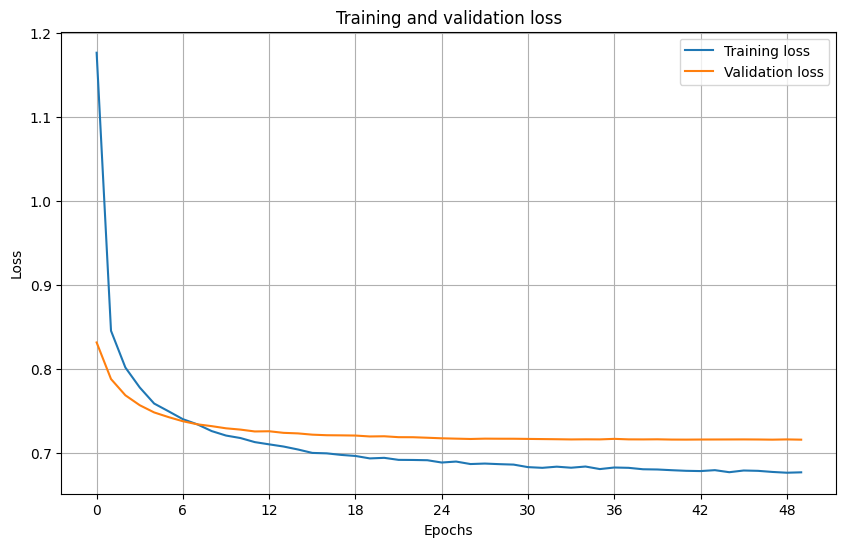

In [20]:
# visualize train and val loss
train_loss = history.history["loss"]
val_loss = history.history.get("val_loss")

plt.figure(figsize=(10, 6))
plt.plot(train_loss, label="Training loss")
plt.plot(val_loss, label="Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid()
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.show()

In [21]:
saving.save_model(model, model_path, include_optimizer=False)

## Evaluate model

### Get predictions on test dataset

In [22]:
test_accuracy = model.evaluate(test_ds)

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.9466 - loss: 0.6655


In [23]:
test2_accuracy = model.evaluate(test2_ds)

37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.8872 - loss: 34.3672


In [24]:
true_labels = []
predicted_labels = []

for images, labels in test_ds:
    # append true labels based on their format
    if len(labels.shape) > 1:  # if one-hot encoded
        true_labels.append(np.argmax(labels.numpy(), axis=1))
    else:  # if integer labels
        true_labels.append(labels.numpy())

    # predict labels
    predictions = model.predict(images)
    predicted_labels.append(np.argmax(predictions, axis=1))

# combine all batches into single arrays
true_labels = np.concatenate(true_labels)
predicted_labels = np.concatenate(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━

### Get performance metrics, classification report and confusion matrix

In [25]:
precision = precision_score(true_labels, predicted_labels, average="macro")
recall = recall_score(true_labels, predicted_labels, average="macro")
f1 = f1_score(true_labels, predicted_labels, average="macro")
print(f"Test accuracy: {test_accuracy[1]:.4f}\nTest2 accuracy: {test2_accuracy[1]:.4f}\nTest precision: {precision:.4f}\nTest recall: {recall:.4f}\nTest f1-score: {f1:.4f}")

Test accuracy: 0.9336
Test2 accuracy: 0.8885
Test precision: 0.9340
Test recall: 0.9336
Test f1-score: 0.9336


In [26]:
cr_dict = classification_report(
    true_labels, predicted_labels, target_names=class_names, output_dict=True
)

# remove scalar 'accuracy'
cr_dict.pop("accuracy", None)

# add micro avg manually
micro_avg = {
    "precision": precision_score(true_labels, predicted_labels, average="micro"),
    "recall": recall_score(true_labels, predicted_labels, average="micro"),
    "f1-score": f1_score(true_labels, predicted_labels, average="micro"),
    "support": len(true_labels),
}
cr_dict["micro avg"] = micro_avg

# reorder: class entries + micro avg + macro avg + weighted avg
ordered_keys = class_names + ["micro avg", "macro avg", "weighted avg"]

# rebuild dict with correct order
ordered_cr_dict = {k: cr_dict[k] for k in ordered_keys if k in cr_dict}

cr_df = pd.DataFrame(ordered_cr_dict).transpose()
cr_df.to_csv(classification_report_path)
print("Classification report:\n", cr_df)

Classification report:
                   precision  recall  f1-score  support
tiger              1.000000  0.9880  0.993964    250.0
leopard            0.932806  0.9440  0.938370    250.0
black_bear         0.959184  0.9400  0.949495    250.0
other_carnivores   0.919679  0.9160  0.917836    250.0
deer               0.912500  0.8760  0.893878    250.0
wild_boar          0.967078  0.9400  0.953347    250.0
buffalo            0.899254  0.9640  0.930502    250.0
rhino              0.906122  0.8880  0.896970    250.0
elephant           0.920949  0.9320  0.926441    250.0
bird               0.922179  0.9480  0.934911    250.0
micro avg          0.933600  0.9336  0.933600   2500.0
macro avg          0.933975  0.9336  0.933571   2500.0
weighted avg       0.933975  0.9336  0.933571   2500.0


In [27]:
cm = confusion_matrix(true_labels, predicted_labels)
print("Confusion matrix:\n", cm)

Confusion matrix:
 [[247   1   0   0   1   0   0   1   0   0]
 [  0 236   0   1   0   1   1   7   2   2]
 [  0   0 235   2   7   1   0   0   3   2]
 [  0   4   0 229  10   0   7   0   0   0]
 [  0   2   4   5 219   3   8   4   3   2]
 [  0   1   3   2   1 235   2   3   1   2]
 [  0   1   0   4   0   3 241   0   0   1]
 [  0   4   1   3   2   0   8 222   5   5]
 [  0   4   1   1   0   0   0   5 233   6]
 [  0   0   1   2   0   0   1   3   6 237]]


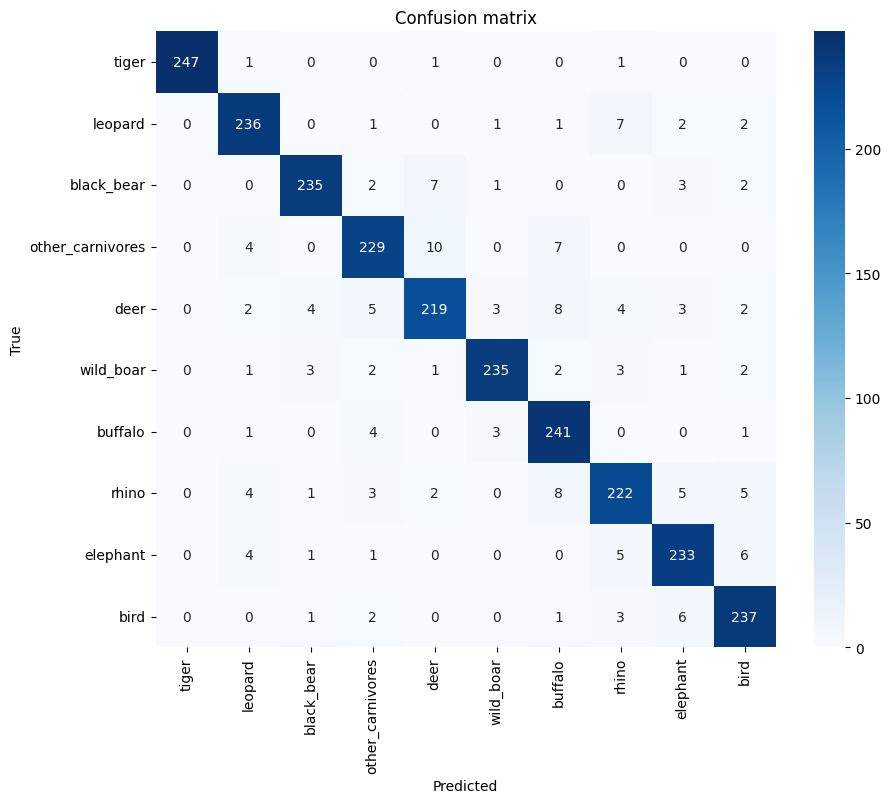

In [28]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix")
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

## Log run to W&B

In [29]:
if use_wandb_logging:
    run = wandb.init(
        project=wb_project,
        config={
            "model_constructor": model_constructor,
            "model_params": model_params,
            "frozen_file_size": frozen_file_size,
            "img_size": img_size,
            "num_classes": num_classes,
            "n_train_images": n_train_images,
            "n_val_images": n_val_images,
            "n_test_images": n_test_images,
            "augmentations": str(apply_augmentations),
            "batch_size": batch_size,
            "epochs": epochs,
        },
    )
    wandb.log(
        {
            "training_time_mins": training_time_mins,
            "test_accuracy": round(test_accuracy[1], 4),
            "test2_accuracy": round(test2_accuracy[1], 4),
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1": round(f1, 4),
        }
    )
    artifact = wandb.Artifact("classification_results", type="evaluation")
    artifact.add_file(classification_report_path)
    artifact.add_file(confusion_matrix_path)
    wandb.log_artifact(artifact)
    wandb.finish()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: alexvmt. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.18.7
wandb: Run data is saved locally in /wandb/run-20260517_212938-2wgj8mi1
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run fallen-frog-32
wandb: ⭐️ View project at https://wandb.ai/alexvmt/TeraiNet
wandb: 🚀 View run at https://wandb.ai/alexvmt/TeraiNet/runs/2wgj8mi1
wandb:                                                                                
wandb: 
wandb: Run history:
wandb:                 f1 ▁
wandb:          precision ▁
wandb:             recall ▁
wandb:     test2_accuracy ▁
wandb:      test_accuracy ▁
wandb: training_time_mins ▁
wandb: 
wandb: Run summary:
wandb:                 f1 0.9336
wandb:          precision 0.934
wandb:             recall 0.9336
wandb:     test2_accuracy 0.8885
wandb:      test_accuracy 0.9336
